In [1]:
# Import the Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading the Data
df = pd.read_csv('Autism Prediction.csv')

In [3]:
# Analyse the Top 5 rows of the data
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [4]:
# Now let's check the size of the data
df.shape

(800, 22)

In [5]:
# Now let's ceck for more information about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    object 
 13  ethnicity        800 non-null    object 
 14  jaundice         800 non-null    object 
 15  austim           800 non-null    object 
 16  contry_of_res    800 non-null    object 
 17  used_app_before 

In [6]:
# Now let's check descriptive stats about the data
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,800.0,400.500000,231.084400,1.000000,200.750000,400.500000,600.250000,800.000000
A1_Score,800.0,0.560000,0.496697,0.000000,0.000000,1.000000,1.000000,1.000000
A2_Score,800.0,0.530000,0.499411,0.000000,0.000000,1.000000,1.000000,1.000000
A3_Score,800.0,0.450000,0.497805,0.000000,0.000000,0.000000,1.000000,1.000000
A4_Score,800.0,0.415000,0.493030,0.000000,0.000000,0.000000,1.000000,1.000000
A5_Score,800.0,0.395000,0.489157,0.000000,0.000000,0.000000,1.000000,1.000000
A6_Score,800.0,0.303750,0.460164,0.000000,0.000000,0.000000,1.000000,1.000000
A7_Score,800.0,0.397500,0.489687,0.000000,0.000000,0.000000,1.000000,1.000000
A8_Score,800.0,0.508750,0.500236,0.000000,0.000000,1.000000,1.000000,1.000000
A9_Score,800.0,0.495000,0.500288,0.000000,0.000000,0.000000,1.000000,1.000000


In [7]:
# Now let's check descriptive stats about the data on categorical column
df.describe(include= 'object').T

,count,unique,top,freq
gender,800,2,m,530
ethnicity,800,12,White-European,257
jaundice,800,2,no,615
austim,800,2,no,669
contry_of_res,800,56,United States,134
used_app_before,800,2,no,750
age_desc,800,1,18 and more,800
relation,800,6,Self,709


### Data Cleaning

In [8]:
df['ethnicity'].value_counts()

ethnicity
White-European     257
?                  203
Middle Eastern      97
Asian               67
Black               47
South Asian         34
Pasifika            32
Others              29
Latino              17
Hispanic             9
Turkish              5
others               3
Name: count, dtype: int64

##### In the above two outputs we can observe some ambiguity that there are '?', 'others', and 'Others' which all must be the same as they are unknown or we can say that null values have been substituted with some indicator.

In [9]:
df['relation'].value_counts()


relation
Self                        709
?                            40
Parent                       29
Relative                     18
Others                        2
Health care professional      2
Name: count, dtype: int64

##### The same is the case with this column so let's clean this data and along with this let's convert 'yes' and 'no' to 0 and 1.




In [10]:
df = df.replace({"yes":1, "no":0, "?": 'Others', "others":"Others"})

In [11]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,Others,0,0,Austria,0,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,Others,0,0,India,0,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,0,1,United States,0,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,Others,0,0,United States,0,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,Others,0,0,South Africa,0,-4.777286,18 and more,Self,0


### Exploratory Data Analysis


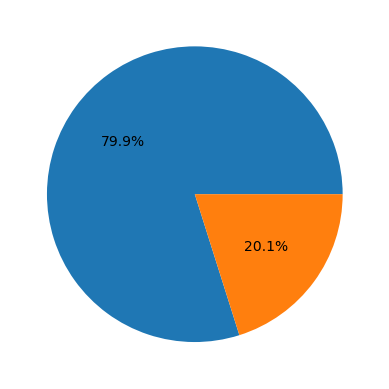

In [12]:
plt.pie(df['Class/ASD'].value_counts().values, autopct= '%1.1f%%')
plt.show()

##### The dataset we have is highly imbalanced. If we will train our model using this data then the model will face a hard time predicting the positive class which is our main objective here to predict whether a person has autism or not with high accuracy.

In [13]:
ints = []
objects = []
floats = []

for col in df.columns:
    if df[col].dtype == int:
        ints.append(col)
    if df[col].dtype == object:
        objects.append(col)
    else:
        floats.append(col)

##### Now, we have columns segregated based on the type of data they contain hence now we'll be able to perform suitable analysis depending upon the type of data.

In [14]:
ints.remove('ID')
ints.remove('Class/ASD')

##### The 'ID' column will contain a unique value for each of the rows and for the column 'Class/ASD' we have already analyzed its distribution so, that is why they have been removed in the above code.

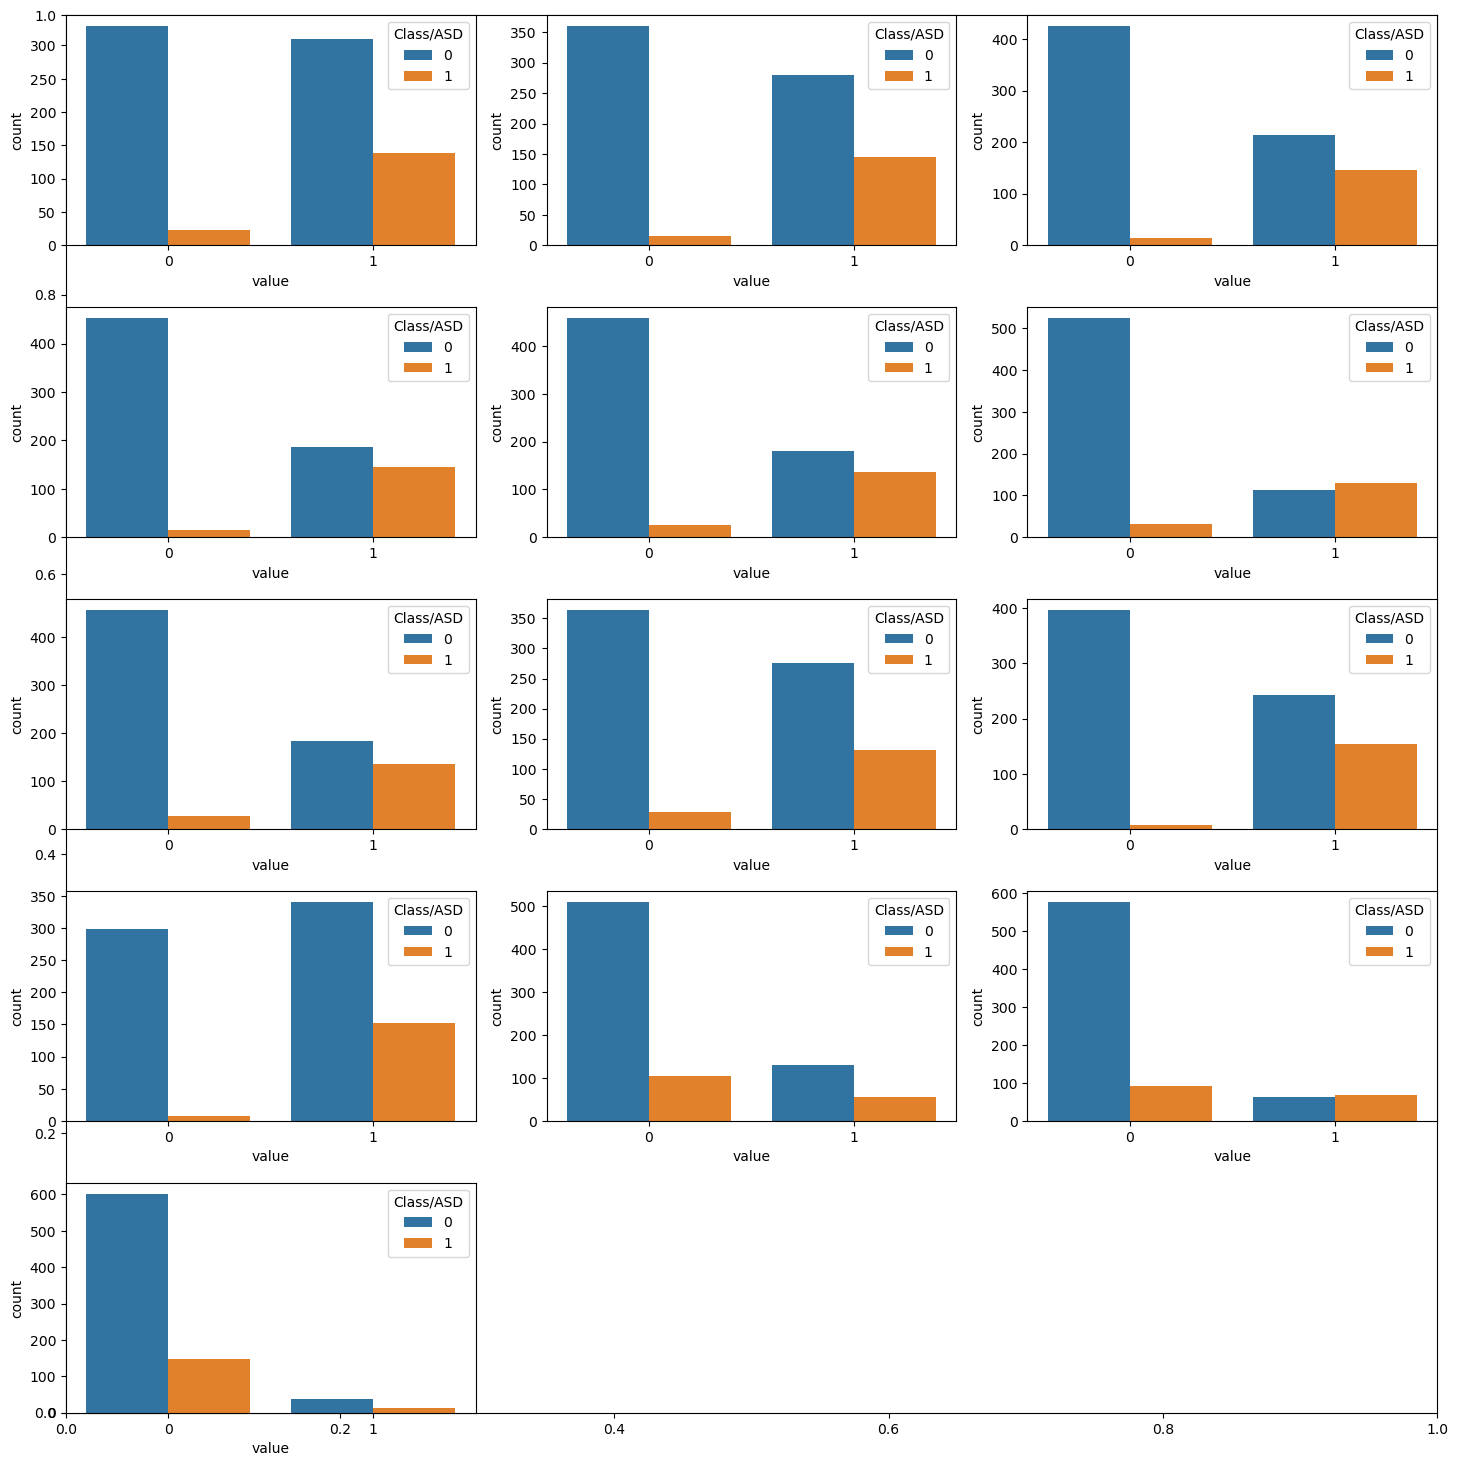

In [15]:
# Convert the data to Long - Form using melt
df_melted = df.melt(id_vars = ['ID','Class/ASD'], value_vars= ints, var_name= 'col', value_name= 'value')

plt.subplots(figsize = (15,15))

for i, col in enumerate(ints):
    plt.subplot(5,3,i+1)

    sns.countplot(x = 'value', hue = 'Class/ASD', data = df_melted[df_melted['col'] == col])

plt.tight_layout()
plt.show()

##### From these plots, we can conclude that if the score of some indicator is 0 then the chances of that person not having autism is quite high except in the case of A10_Score.

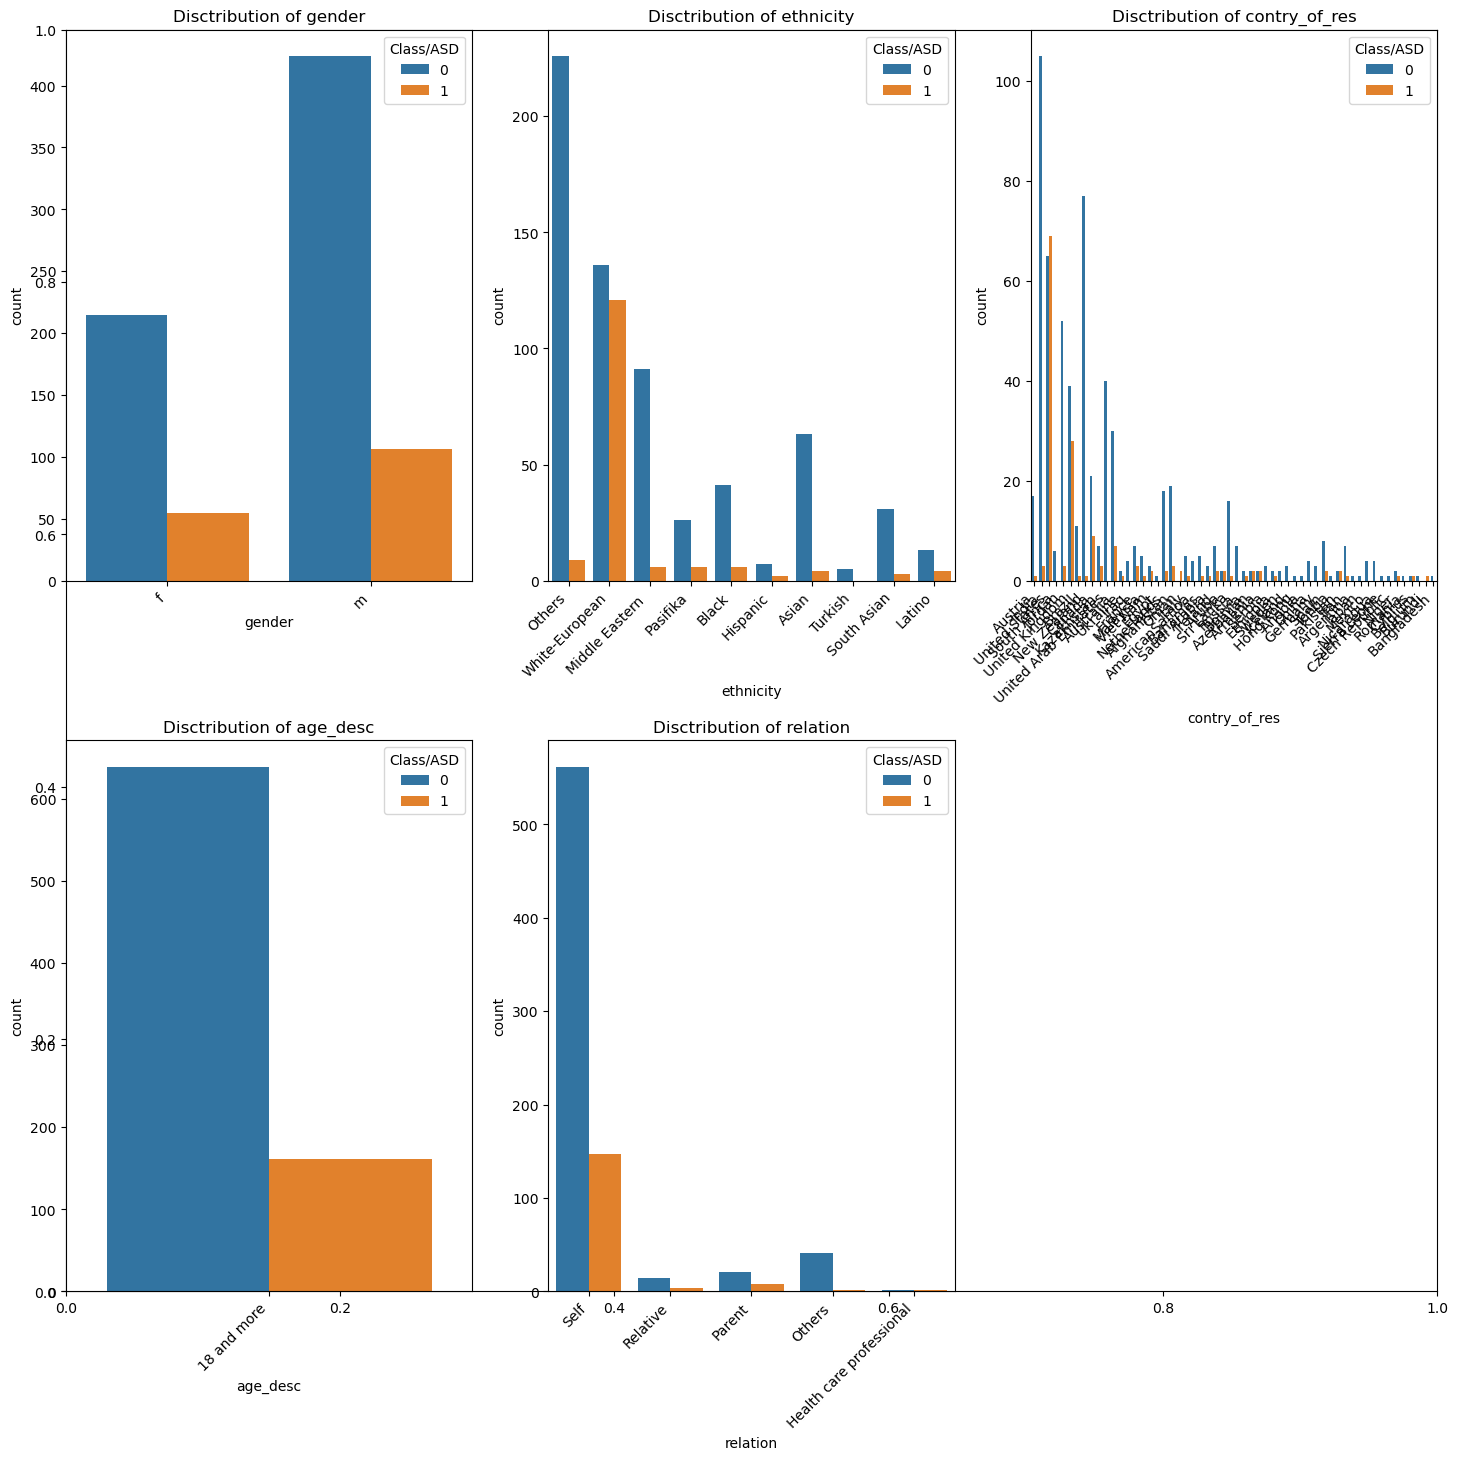

In [16]:
plt.subplots(figsize = (15, 15))

for i, col in enumerate(objects):
    plt.subplot(2, 3, i +1)
    sns.countplot(x = col, hue = 'Class/ASD', data = df)
    plt.title(f'Disctribution of {col}')
    plt.xticks(rotation = 45, ha = 'right')

plt.tight_layout()
plt.show()

##### From the above plots we can draw the following observations:

- Age_desc is the same for all the data points.
- This used_app_before feature doesn't seem to be useful or it will be the source of data leakage.
- Here it seems like the chances of a male having autism is higher than a female but that is not true because we don't have an equal number of examples of males and females.

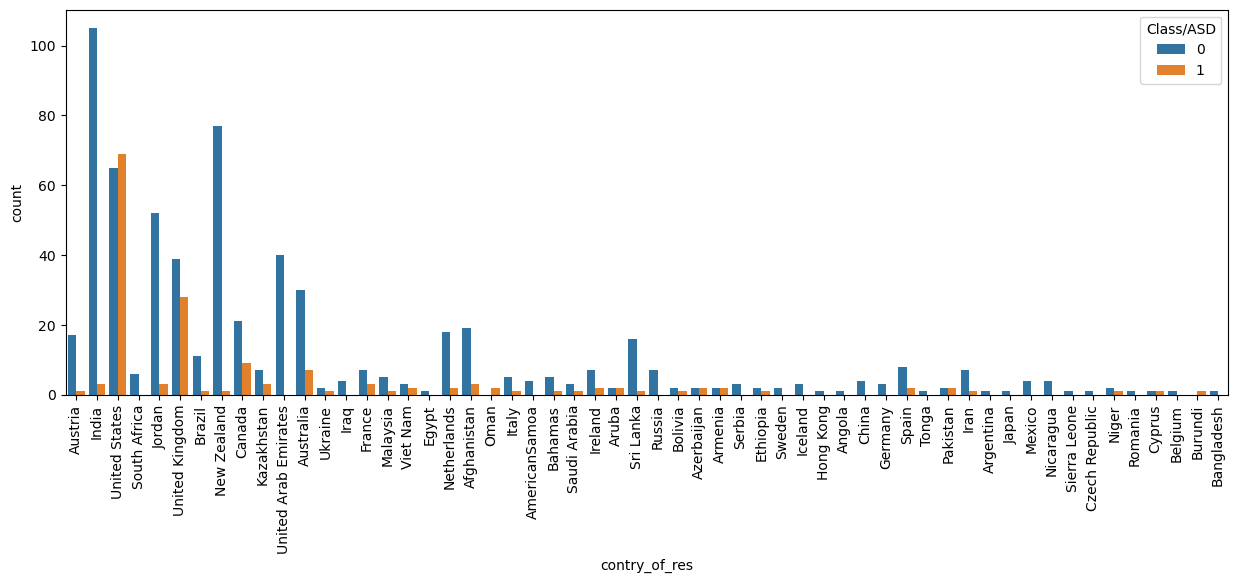

In [17]:
plt.figure(figsize = (15,5))
sns.countplot(data = df, x = 'contry_of_res', hue = 'Class/ASD')
plt.xticks(rotation = 90)
plt.show()

##### In some places approximately 50% of the data available for that country have autism and in some places, this is quite low. This implies that the geography of a person also gives an idea of having autism.

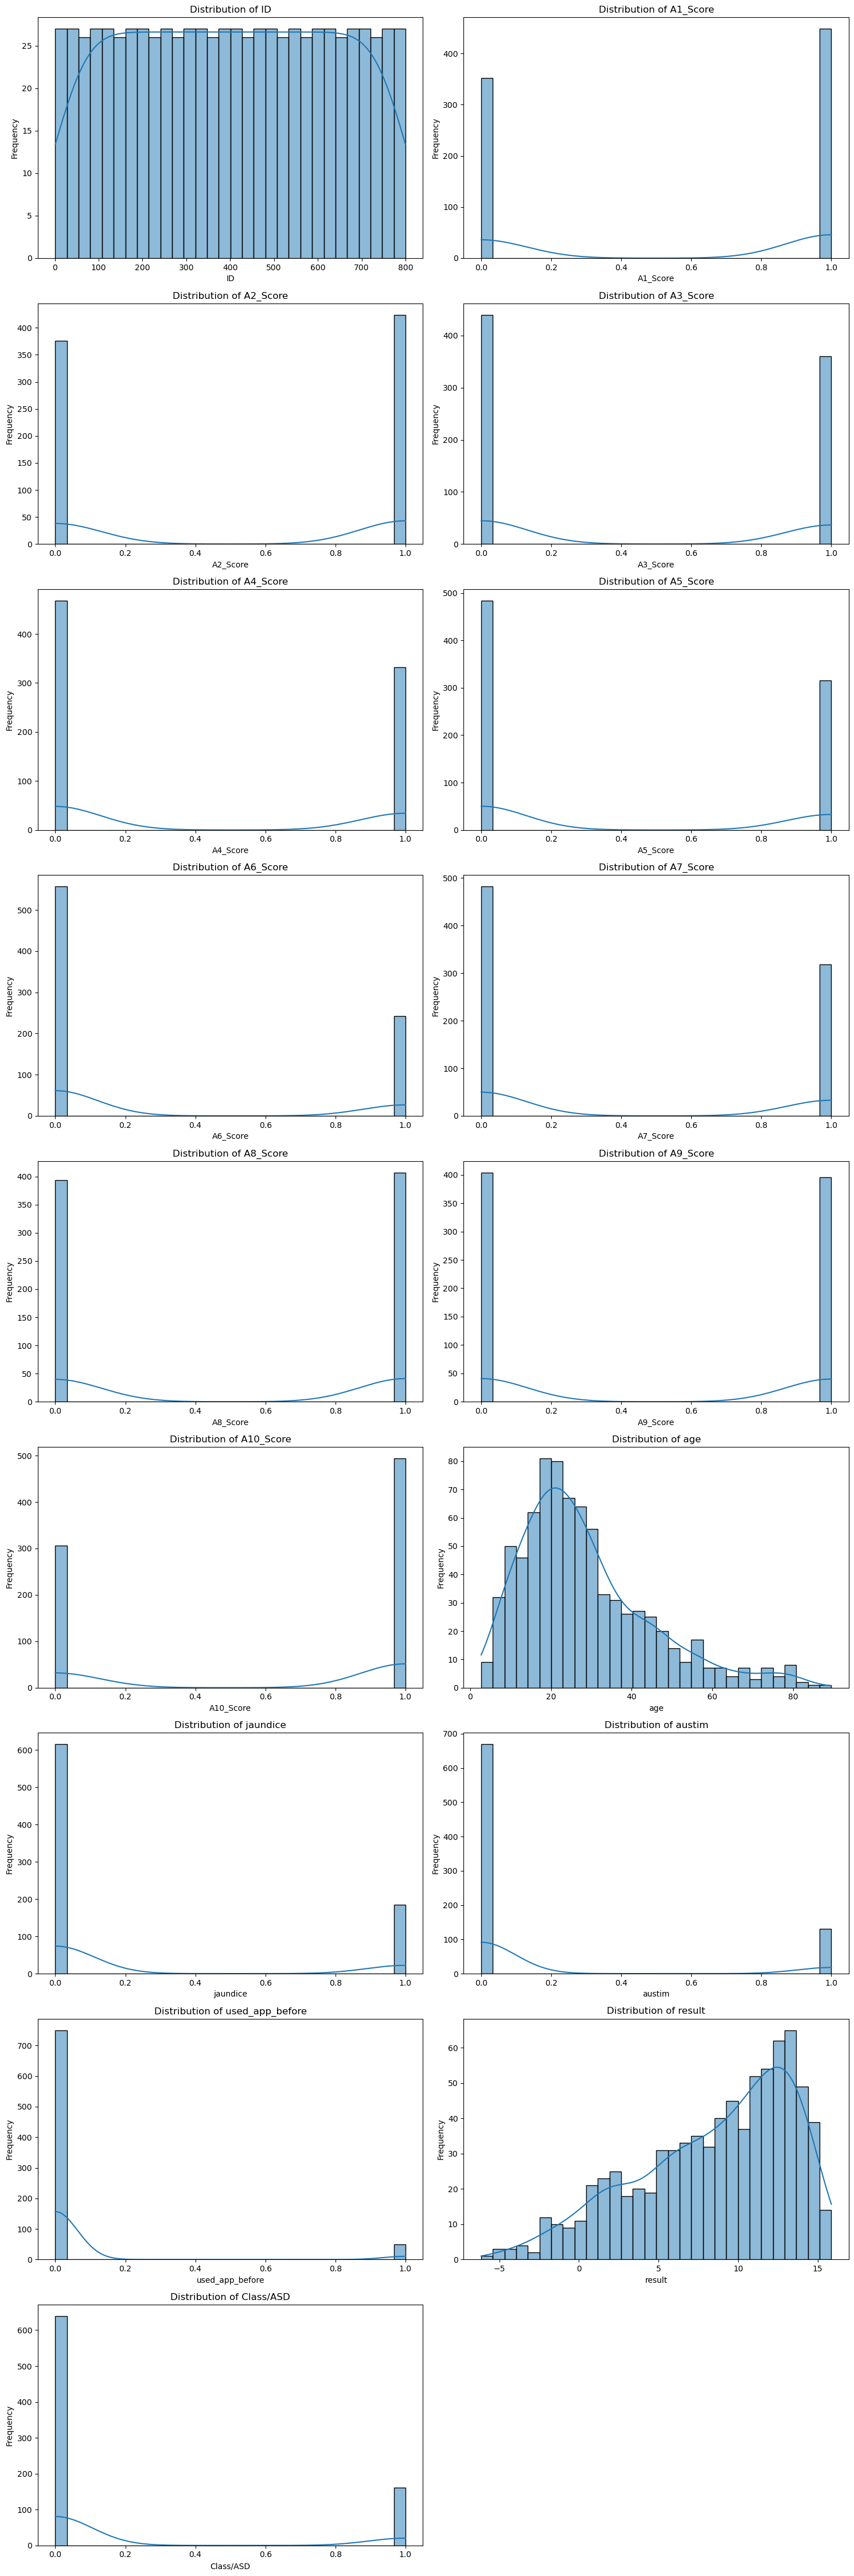

In [18]:
# Number of features
n = len(floats)

# Calculate rows and columns dynamically
cols = 2
rows = (n + 1) // cols  # ensures all plots fit

# Create figure
plt.figure(figsize=(15, 5 * rows))

# Plot each float column
for i, col in enumerate(floats):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### Age and Result both of the continuous data are skewed left one is positive and the right one is negatively skewed.




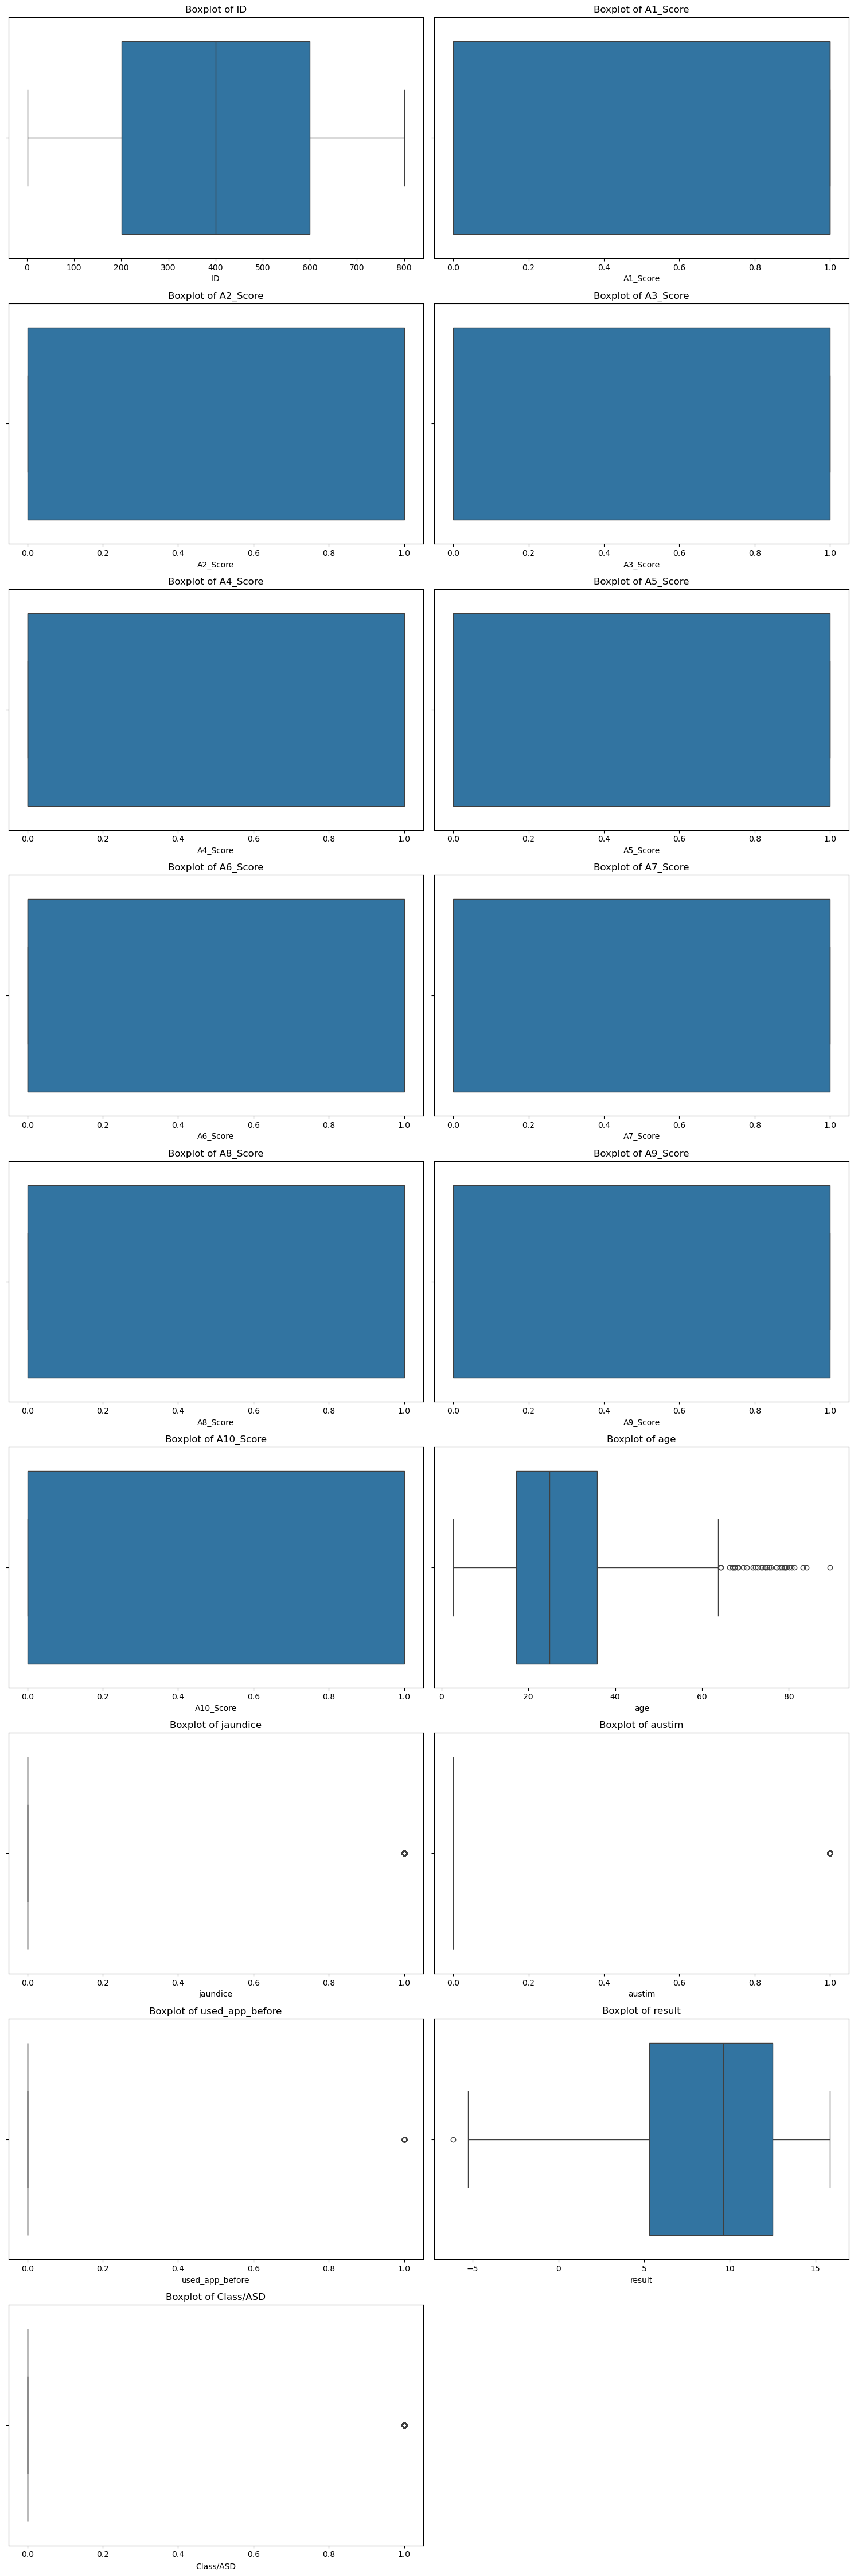

In [19]:
n = len(floats)

# Dynamic rows and columns for layout
cols = 2
rows = (n + 1) // cols  # auto-calculate rows needed

# Set the figure size
plt.figure(figsize=(15, 5 * rows))

# Loop through and create subplots
for i, col in enumerate(floats):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

##### We can see some outliers in the result column. Let's remove that as it doesn't seem like too much loss of information.




In [20]:
df = df[df['result']>-5]
df.shape

(798, 22)

### Feature Engineering

In [21]:
def convertAge(age):
    if age < 4:
        return 'Toddler'
    elif age < 12:
        return 'Kid'
    elif age < 18:
        return 'Teenager'
    elif age < 40:
        return 'Young'
    else:
        'Senior'

df['agegroup'] = df['age'].apply(convertAge)

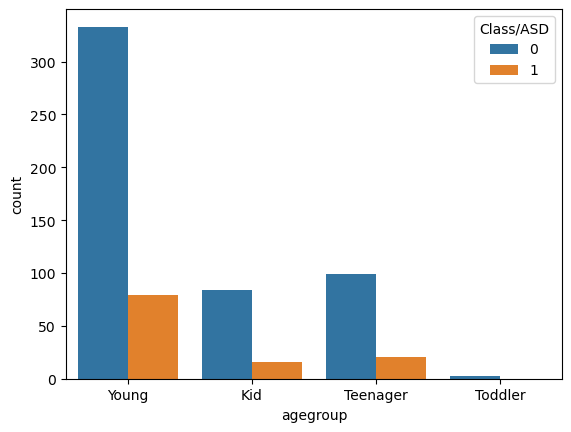

In [22]:
# Now, let's explore the number of cases for each age group.

sns.countplot(x = df['agegroup'], hue = df['Class/ASD'])
plt.show()

##### Here we can conclude that the Young and Toddler group of people have lower chances of having Autism.

In [23]:
def add_feature(data):

    data['sum_score'] = 0
    for col in data.loc[:, 'A1_Score': 'A10_Score'].columns:

        data['sum_score'] += data[col]

    data['ind'] = data['austim'] + data['used_app_before'] + data['jaundice']

    return data

df = add_feature(df)

##### In the above code we have just summed up the clinical scores given from A1 to A10.

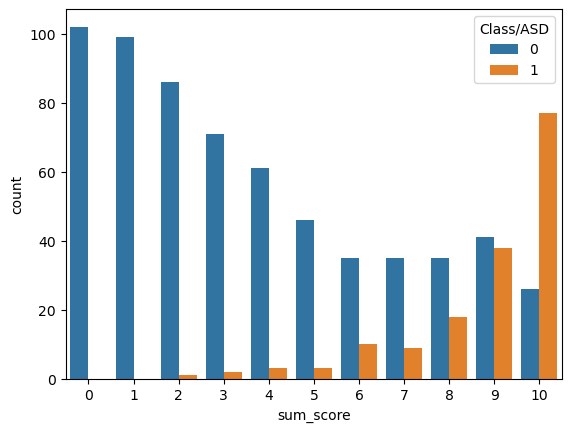

In [24]:
sns.countplot(x=df['sum_score'], hue=df['Class/ASD'])
plt.show()

##### Another amazing observation is that higher the sum score higher the chances of having autism and similarly sum scores less than 5 means person has rare chance of autism.

In [25]:
# Allyling log transformations to remove the skweness of the data
df['age'] = df['age'].apply(lambda x: np.log(x))

##### The age data given to us is positively skewed. As we know that skewed data impacts the performance of the model we will apply log transformations to remove the skewness of the data.

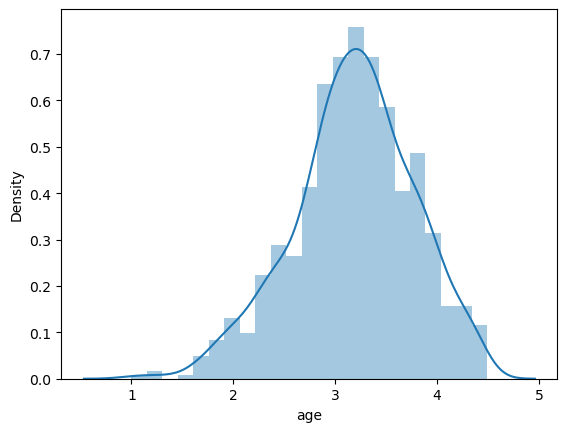

In [26]:
sns.distplot(df['age'])
plt.show()

##### Now the skewness of the data has been removed successfully by using the log transformations.

In [27]:
def encode_labels(data):
    for col in data.columns:

        if data[col].dtype == 'object':
            le = LabelEncoder()
            data[col] = le.fit_transform(data[col])

        return data

df = encode_labels(df)

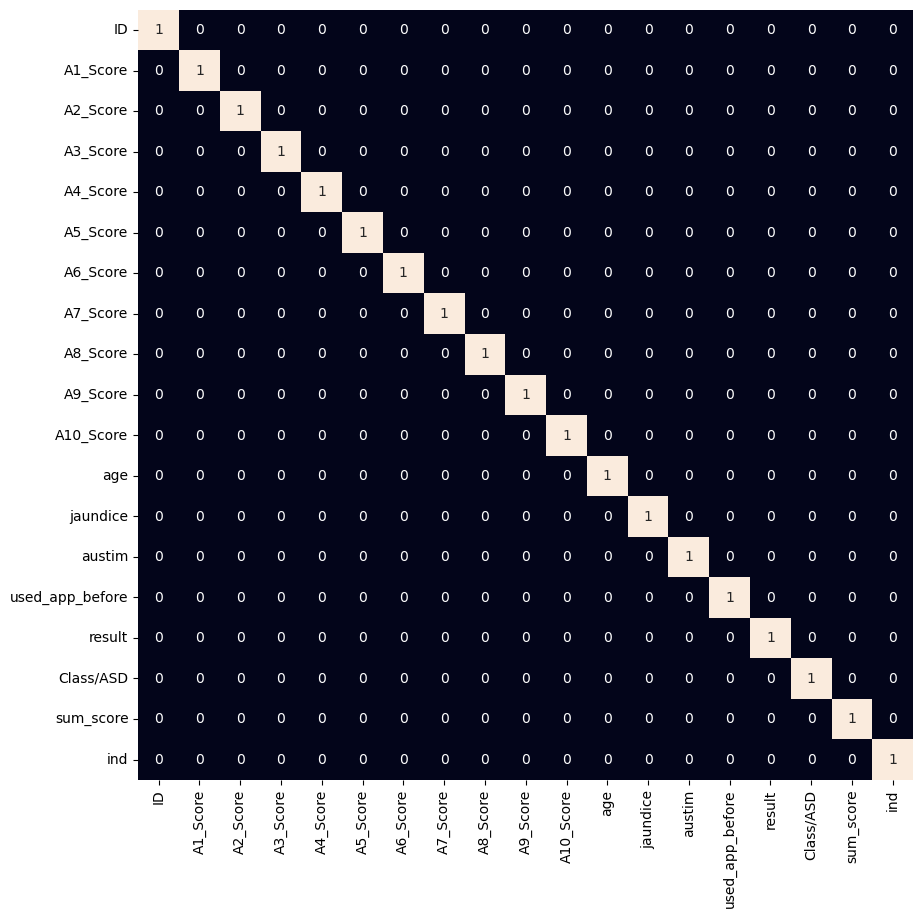

In [28]:
plt.figure(figsize = (10,10))
sns.heatmap(df.corr(numeric_only= True) > 0.8, annot= True, cbar= False )
plt.show()

##### From the above heat map we can see that there are only one highly correlated features which we will remove before training the model on this data as highly correlated features do not help in learning useful patterns in the data.

### Model Training

In [29]:
# Now we will separate the features and target variables and split them into training and the testing data by using which we will select the model which is performing best on the validation data.
removal = ['gender', 'ethnicity', 'contry_of_res', 'relation', 'agegroup', 'age_desc']
features = df.drop(removal + ['Class/ASD'], axis = 1)
target = df['Class/ASD']

In [30]:
# Let's split the data into training and validation data
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size= 0.2, random_state= 42)

In [31]:
# Also the data was imbalanced earlier now we will balance it using the Random Over Sampler in this method we sample some points from the minority class and repeat it multiple times so, that the two classes get balanced.
ros = RandomOverSampler(sampling_strategy= 'minority', random_state= 0)
X, Y = ros.fit_resample(x_train, y_train)
X.shape, Y.shape

((1028, 18), (1028,))

In [35]:
# Now, let's normalize the data to obtain stable and fast training.
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_val = scaler.transform(x_test)

In [36]:
# Now let's train some state-of-the-art machine learning models and compare them which fit better with our data.
models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]

for model in models:
  model.fit(X, Y)

  print(f'{model} : ')
  print('Training Accuracy : ', metrics.roc_auc_score(Y, model.predict(X)))
  print('Validation Accuracy : ', metrics.roc_auc_score(y_test, model.predict(X_val)))
  print()


LogisticRegression() : 
Training Accuracy :  0.8394941634241245
Validation Accuracy :  0.5

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...) : 
Training Accuracy :  1.0
Validation Accuracy :  0.7642276422764227

SVC() : 
Training Accuracy :  0.9299610894941635
Validation Accuracy :  0.5


#### From the above accuracies we can say that XGBClassifier perform better on the validation data with less difference between the validation and training data. The disease for which there are no diagnostics methods machine learning models are able to predict whether the person has Autism or not. This is where machine learning helps in real-world problems and solving them.